# Multistory Dissimilarity Matrix

## Set Up Environment

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial

from scenario2_utils import (
    compute_adp_dissimilarity_matrix,
    compute_geodesic_dissimilarity_matrix,
    floor_sample_indices,
    load_dataset_artifacts,
    load_estimated_floor_indices,
    plot_dissimilarity_over_euclidean_distance,
    plot_scene_overview,
    save_npz_array_dict,
    scale_dissimilarity_matrix_to_meters,
 )

## Load Data and Floor Partitions

In [2]:
dataset = load_dataset_artifacts(include_geometry=True)
csi_freq_domain_train = dataset.csi_freq_domain_train
groundtruth_positions_train = dataset.groundtruth_positions_train
array_positions_3D = dataset.array_positions_3d
center_positions_3D = dataset.center_positions_3d
floor_nr = dataset.floor_nr
estimated_floor_indices = load_estimated_floor_indices()

print("Shape of csi_freq_domain_train: ", csi_freq_domain_train.shape)
print("Shape of groundtruth_positions_train: ", groundtruth_positions_train.shape)
print("Shape of array_positions_3D: ", array_positions_3D.shape)
print("Shape of center_positions_3D: ", center_positions_3D.shape)
print("floor_nr: ", floor_nr)
print("Shape of estimated floor: ", estimated_floor_indices.shape)

Shape of csi_freq_domain_train:  (5000, 5, 4, 2, 4, 64)
Shape of groundtruth_positions_train:  (5000, 3)
Shape of array_positions_3D:  (5, 4, 3)
Shape of center_positions_3D:  (5, 3)
floor_nr:  5
Shape of estimated floor:  (5000,)


## Optional: Visualize Dataset

In [3]:
SHOW_DATASET_PREVIEW = False

if SHOW_DATASET_PREVIEW:
    plot_scene_overview(
        groundtruth_positions_train,
        array_positions_3D,
        center_positions_3D,
    )

## Compute Floor-Wise Dissimilarity Matrices

### Build Floor-Wise CSI Inputs

In [4]:
csi_freq_domain_train.shape

(5000, 5, 4, 2, 4, 64)

In [5]:
#csi_time_domain = np.fft.fftshift(np.fft.ifft(np.fft.fftshift(csi_freq_domain_train, axes = -1)), axes=-1)[...,27:40]

In [6]:
#csi_time_domain.shape

In [7]:
csi_metric_input = csi_freq_domain_train

In [8]:
sample_indices_by_floor = {
    floor_index: floor_sample_indices(estimated_floor_indices, floor_index)
    for floor_index in range(floor_nr)
}

### Compute ADP Dissimilarities Per Floor

In [9]:
adp_dissimilarity_matrix_by_floor = {}

for floor_index in range(floor_nr):
    print("floor index: {}".format(floor_index))

    sample_indices = sample_indices_by_floor[floor_index]
    csi_metric_input_floor = csi_metric_input[sample_indices][:, np.arange(floor_nr) != floor_index]
    csi_metric_input_floor = csi_metric_input_floor.reshape((
        csi_metric_input_floor.shape[0],
        -1,
        csi_metric_input_floor.shape[3],
        csi_metric_input_floor.shape[4],
        csi_metric_input_floor.shape[5],
    ))

    print("CSI shape: {}".format(csi_metric_input_floor.shape))
    adp_dissimilarity_matrix_by_floor[floor_index] = compute_adp_dissimilarity_matrix(csi_metric_input_floor)

floor index: 0
CSI shape: (999, 16, 2, 4, 64)


100%|██████████| 998001/998001 [00:06<00:00, 166052.77it/s]


floor index: 1
CSI shape: (1001, 16, 2, 4, 64)


100%|██████████| 1002001/1002001 [00:06<00:00, 163619.10it/s]

floor index: 2
CSI shape: (1001, 16, 2, 4, 64)



100%|██████████| 1002001/1002001 [00:06<00:00, 163140.69it/s]


floor index: 3
CSI shape: (1012, 16, 2, 4, 64)


100%|██████████| 1024144/1024144 [00:06<00:00, 162739.67it/s]


floor index: 4
CSI shape: (987, 16, 2, 4, 64)


100%|██████████| 974169/974169 [00:06<00:00, 160831.99it/s]


### Compute and Scale Geodesic Distances Per Floor

In [10]:
n_neighbors = 20

dissimilarity_matrix_geodesic_by_floor = {}
groundtruth_distance_matrix_by_floor = {}

for floor_index in range(floor_nr):
    print("floor index: {}".format(floor_index))

    sample_indices = sample_indices_by_floor[floor_index]
    groundtruth_positions_floor = groundtruth_positions_train[sample_indices]
    groundtruth_distance_matrix_by_floor[floor_index] = scipy.spatial.distance_matrix(
        groundtruth_positions_floor,
        groundtruth_positions_floor,
    )

    dissimilarity_matrix_geodesic = compute_geodesic_dissimilarity_matrix(
        adp_dissimilarity_matrix_by_floor[floor_index],
        n_neighbors=n_neighbors,
    )
    dissimilarity_matrix_geodesic_by_floor[floor_index] = scale_dissimilarity_matrix_to_meters(
        dissimilarity_matrix_geodesic,
        groundtruth_positions_floor,
        reduction=1,
    )

floor index: 0
floor index: 1
floor index: 2
floor index: 3
floor index: 4


### Compare Geodesic and ADP Dissimilarities

floor index: 0


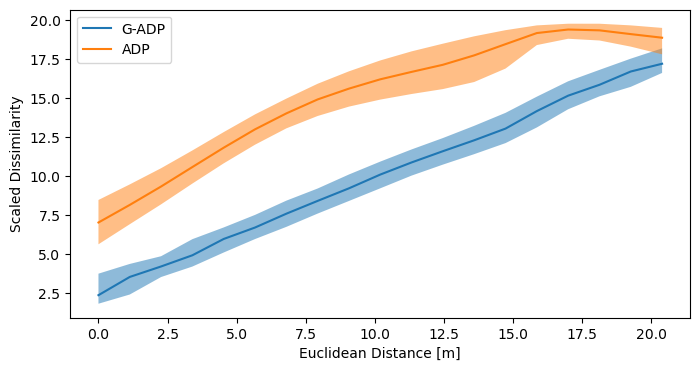

floor index: 1


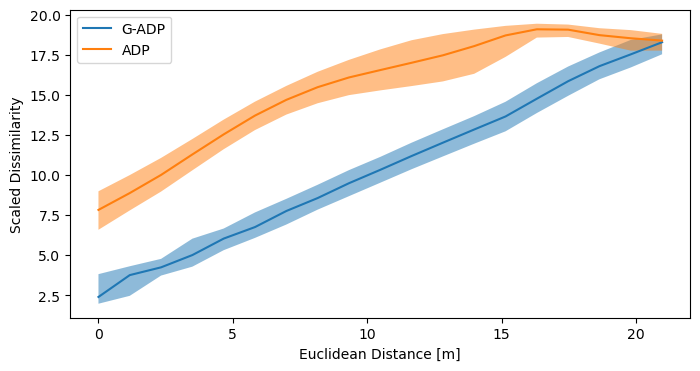

floor index: 2


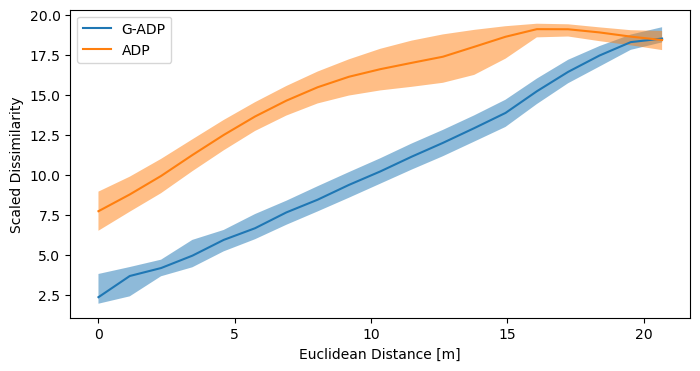

floor index: 3


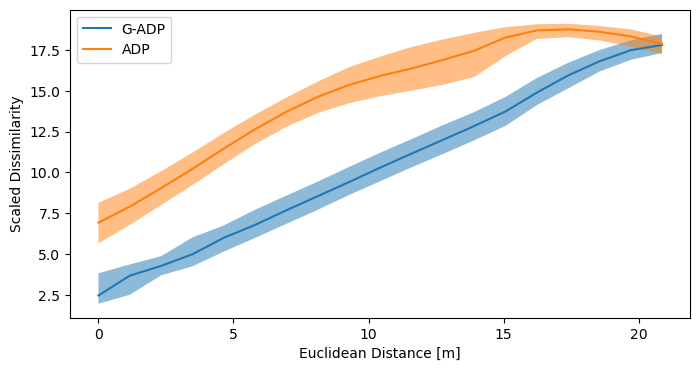

floor index: 4


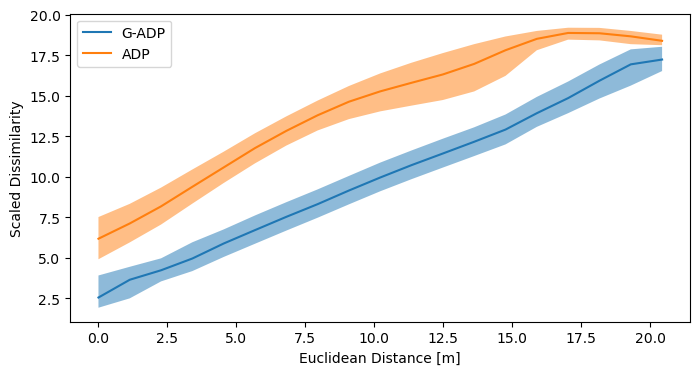

In [11]:
for floor_index in range(floor_nr):
    print("floor index: {}".format(floor_index))

    plt.figure(figsize=(8, 4))
    scaling_factor = np.max(dissimilarity_matrix_geodesic_by_floor[floor_index]) / np.max(adp_dissimilarity_matrix_by_floor[floor_index])
    plot_dissimilarity_over_euclidean_distance(
        dissimilarity_matrix_geodesic_by_floor[floor_index],
        groundtruth_distance_matrix_by_floor[floor_index],
        "G-ADP",
        bin_count=20,
    )
    plot_dissimilarity_over_euclidean_distance(
        scaling_factor * adp_dissimilarity_matrix_by_floor[floor_index],
        groundtruth_distance_matrix_by_floor[floor_index],
        "ADP",
        bin_count=20,
    )

    plt.legend()
    plt.xlabel("Euclidean Distance [m]")
    plt.ylabel("Scaled Dissimilarity")
    plt.show()

### Save Floor-Wise Dissimilarity Matrices

In [12]:
save_npz_array_dict(
    "results/dissimilarity_matrix_geodesic_by_floor.npz",
    dissimilarity_matrix_geodesic_by_floor,
 )